
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
Analyse univariée
</p>

---



Après avoir nettoyé les données, 
on réalise une analyse statistique univariée,
dont le but est d'observer la répartition des valeurs d'une seule variable à la fois.

Sous-sections :
[Décrire les données](#decrire)&nbsp;|
[Visualiser la distribution des valeurs de chaque variable](#distribution)&nbsp;|
[Traiter les valeurs aberrantes](#outliers)&nbsp;|
[Traiter les valeurs manquantes](#missing)&nbsp;|
[Précisions sur l'encodage](#encodage)&nbsp;|
[Exercices](#exercices)&nbsp;

<a id="decrire"></a>
### Décrire les données

Dans ce notebook, nous illustrerons les différentes notions à l'aide des jeux de données Iris, Breast et Zoo :

`df.head()` affiche les premières lignes du jeu de données :

In [29]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
import pandas as pd

features = ['id', 'clump', 'uniformity_cell_size', 'uniformity_cell_shape', 'marginal_adhesion','single_epithelial_cell_size', 'bare_nuclei', 'chromatin', 'normal_nucleoli', 'mitoses']
cls_att = 'class'
breast = pd.read_csv('../data/breast-cancer-wisconsin.data.with_null',names=features+[cls_att])
breast = breast.set_index('id')
breast.head()

,clump,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,chromatin,normal_nucleoli,mitoses,class
id,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,2
1002945,5,4,4,5,7,10.0,3,2,1,2
1015425,3,1,1,1,2,2.0,3,1,1,2
1016277,6,8,8,1,3,4.0,3,7,1,2
1017023,4,1,1,3,2,1.0,3,1,1,2


In [31]:
import pandas as pd
col_names = ['id',"hair", "feathers", 'eggs', 'milk', 'airborne', 'aquatic', 'predator','toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tails', 'domestic', 'catsize','type']
zoo = pd.read_csv('../data/zoo.data',index_col=0,names=col_names)
zoo.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tails,domestic,catsize,type
id,,,,,,,,,,,,,,,,,
aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


##### Le dictionnaire des données

La première chose qu'on fait lorsqu'on a un nouveau jeu de données, c'est de faire un dictionnaire des données, c'est-à-dire de décrire le nom de chaque variable, son type et l'ensemble des valeurs ($V$) qu'elle prend.

On distingue plusieurs types de variables :
- des variables quantitatives
    - continues ($V\subset\mathbb{R}$)
    - discrètes ($V\subset\mathbb{N}$)
- des variables qualitatives
    - catégorielle nominale (e.g., $V = \{\mathrm{marié}, \mathrm{célibataire}, \mathrm{veuf}\}$)
    - catégorielle ordinale (e.g., $V = \{\mathrm{petit}, \mathrm{moyen}, \mathrm{grand}\}$)
    - binaire ($V = \{0, 1\}$)
- autres variables
    - date
    - texte

On peut lister pour chaque variable la liste des valeurs qu'elle prend dans le jeu de données :

In [32]:
zoo['type'].unique()

array([1, 4, 2, 7, 6, 5, 3])

ainsi que l'effectif pour chaque modalité :

In [33]:
zoo['type'].value_counts()

type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

éventuellement on peut visualiser la répartition de ces valeurs :

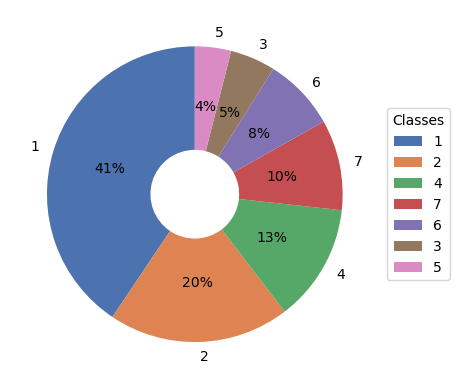

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
colors = sns.color_palette('deep')

fig, ax = plt.subplots()
counts = zoo['type'].value_counts()

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    startangle=90,
    autopct='%.0f%%',
    wedgeprops=dict(width=0.7)
)

ax.legend(wedges, counts.index, title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.7, 1))

Pour chaque attribut, on peut lister quelques statistiques (nombre de valeurs, moyenne, médiane, Q1, Q3, écart type, max) :

In [35]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


On peut aussi regarder si certaines variables ont une petite variance (peu utiles si c'est le cas) :

In [36]:
iris.iloc[:,:-1].var()

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

<a id="distribution"></a>
### Visualiser la distribution des valeurs de chaque variable

La première chose qu'on fait c'est de visualiser la distribution des valeurs prises par chaque variable :

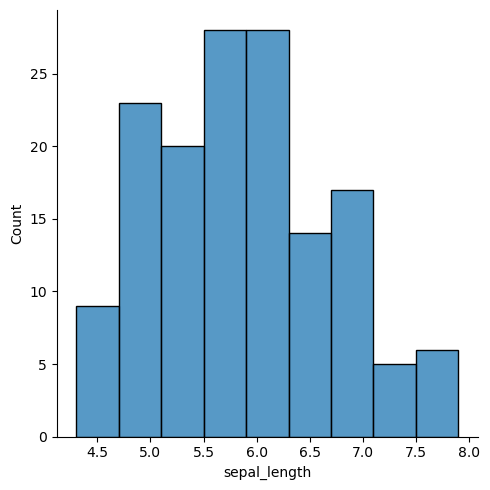

In [37]:
sns.displot(iris,x='sepal_length')

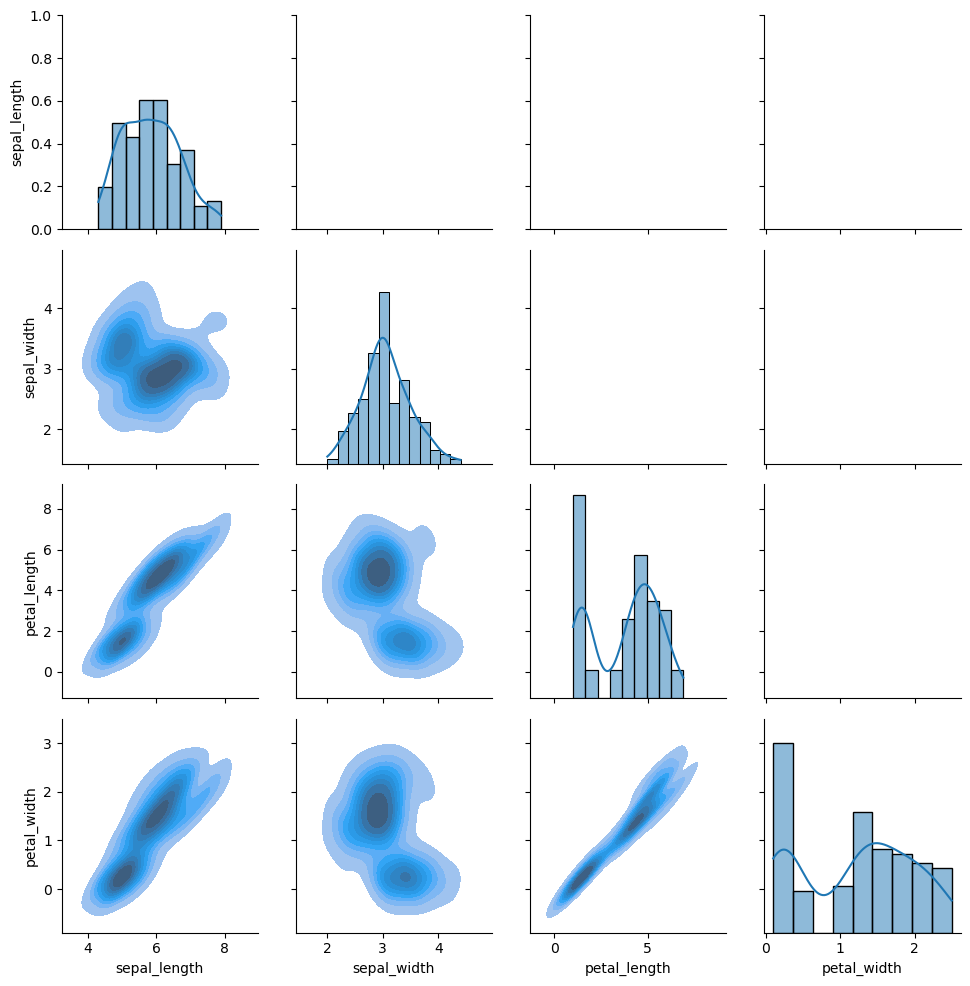

In [38]:
g = sns.PairGrid(iris)
#g.map_upper(sns.histplot)
g.map_lower(sns.kdeplot, fill=True)
g.map_diag(sns.histplot, kde=True)

On peut aussi visualiser la distribution de la variable pour chacune des classes :

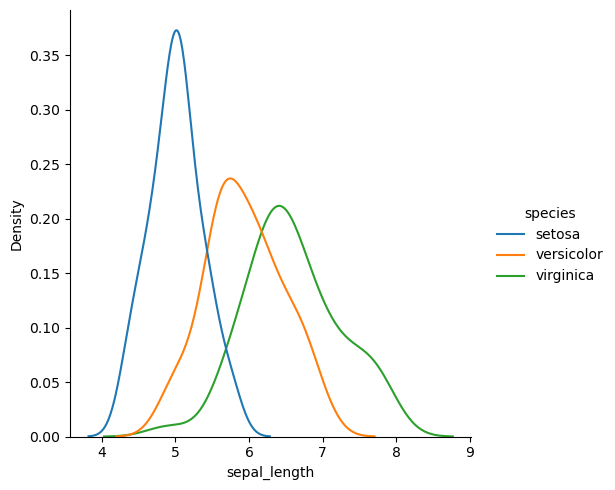

In [39]:
sns.displot(iris,x='sepal_length', hue='species', kind='kde')

<a id="outliers"></a>
### Traiter les valeurs aberrantes

On peut tracer la médiane / les quartiles pour chaque variable :

<Axes: >

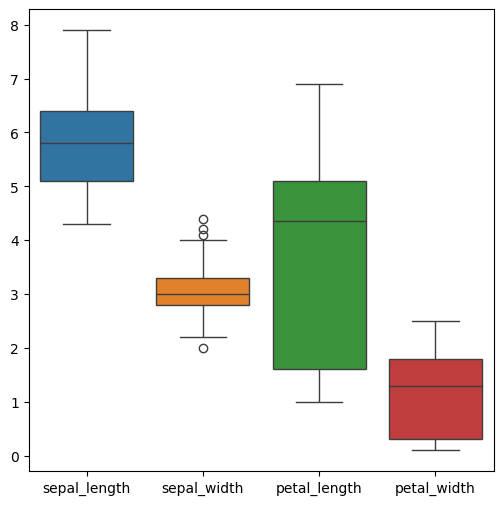

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (6,6))
sns.boxplot(iris.iloc[:,:-1])

ou entre la classe `setosa` et les autres classes :

<Axes: ylabel='sepal_width'>

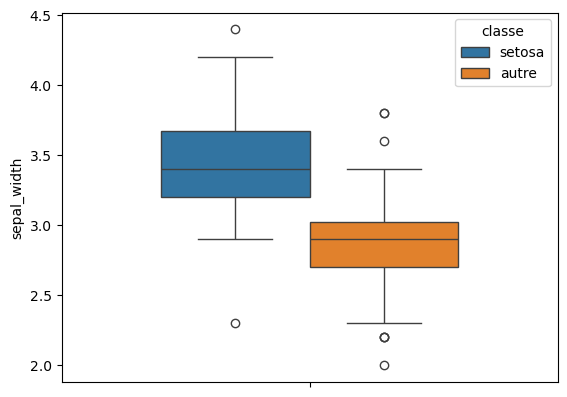

In [ ]:
import numpy as np
import pandas as pd
df = iris.copy()
conditions = [(df['species'] == 'setosa'), (df['species'] != 'setosa') ]
values = (1.,0.)
df['classe'] = pd.Series(np.select(conditions, values)).map({1.:'setosa', 0.:'autre'})
sns.boxplot(df,y='sepal_width', hue='classe', width=.6)


On  voit que certaines variables ont des valeurs aberrantes (les ronds sur la figure).

Une stratégie communément utilisée pour détecter les valeurs aberrantes consiste à considérer qu'une valeur d'attribut aberrante est une valeur qui n'est pas dans l’intervalle

$\mathrm{[Q1 − 1, 5 × (Q3 − Q1), Q3 + 1, 5 × (Q3 − Q1)]}$

où Q1 et Q3 désignent respectivement le premier et le
troisième quantile des valeurs de l'attribut :

![lepcam](../images/lepcam.png)

La fonction `find_outliers_IQR()` suivante permet de trouver ces valeurs aberrantes pour une colonne donnée de la
table. 

In [41]:
def find_outliers_IQR(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    IQR = q3 - q1
    outliers = col.loc[(col < (q1 - 1.5 * IQR)) | (col > (q3 + 1.5 * IQR))]
    return outliers

Par exemple, l'instruction suivante renvoie les lignes de la table dont la valeur de l’attribut sepal_width est aberrante :


In [42]:
find_outliers_IQR(iris['sepal_width'])

15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal_width, dtype: float64

Utiliser la fonction `find_outliers_IQR()` pour trouver quels sont les attributs de la table `iris` qui contiennent des valeurs aberrantes.

In [43]:
for feature in iris.columns[:-1]:
    col = iris[feature]
    outliers = find_outliers_IQR(col)
    if len(outliers) > 0:
        print(f'{feature:10} {len(outliers)}')

outlier_indices = find_outliers_IQR(iris['sepal_width']).index
outliers = iris.iloc[outlier_indices]

outlier_indices, outliers

sepal_width 4


(Index([15, 32, 33, 60], dtype='int64'),
     sepal_length  sepal_width  petal_length  petal_width     species
 15           5.7          4.4           1.5          0.4      setosa
 32           5.2          4.1           1.5          0.1      setosa
 33           5.5          4.2           1.4          0.2      setosa
 60           5.0          2.0           3.5          1.0  versicolor)

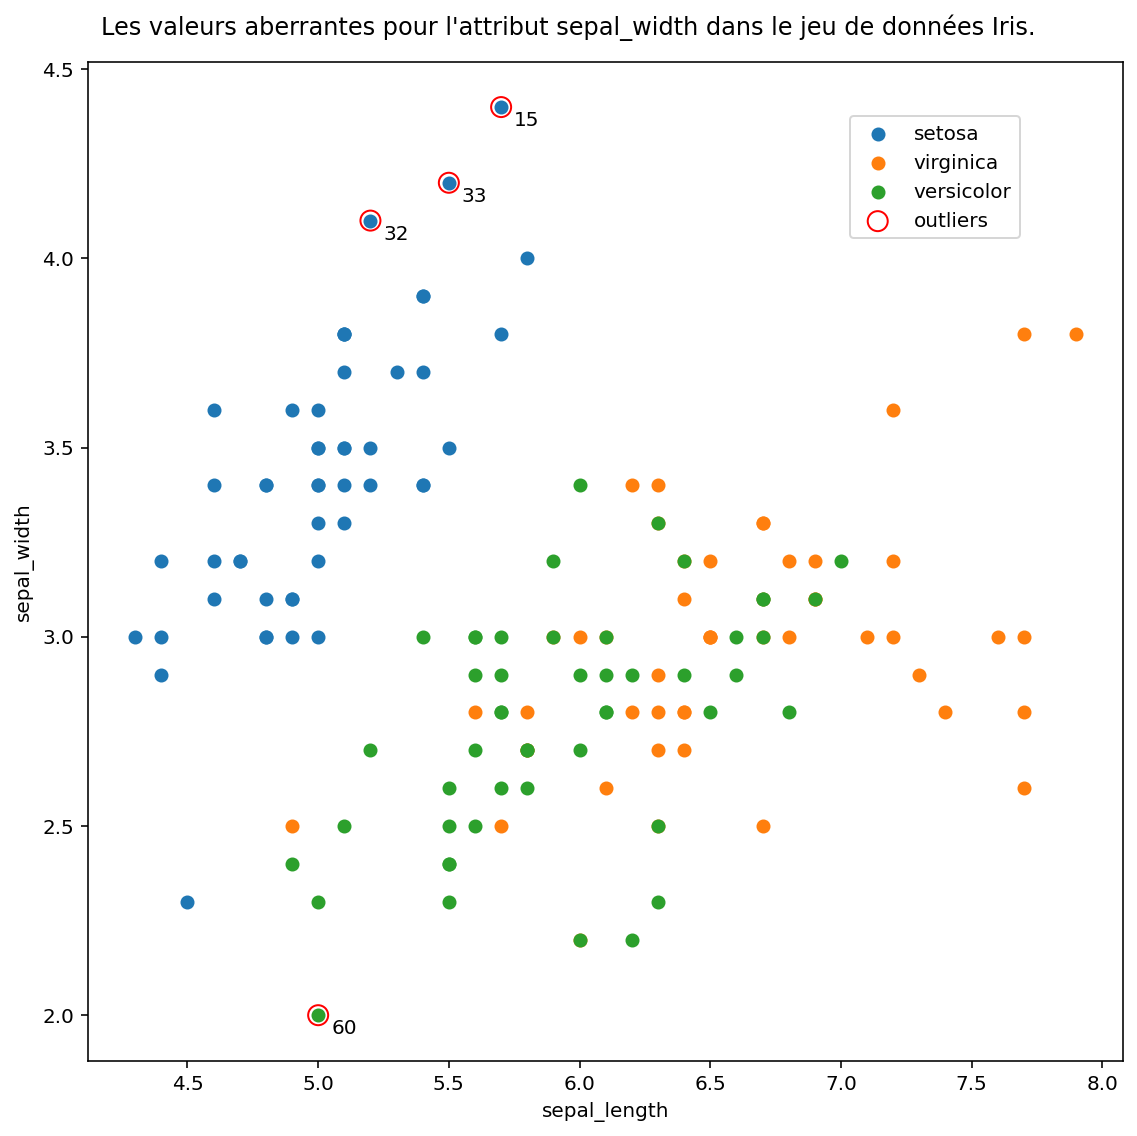

In [44]:
fig, ax = plt.subplots(figsize=(8,8), dpi=144)

setosa = iris.loc[iris['species'] == 'setosa']
virginica = iris.loc[iris['species'] == 'virginica']
versicolor = iris.loc[iris['species'] == 'versicolor']



for df in [setosa, virginica, versicolor]:
	ax.scatter(df['sepal_length'],df['sepal_width'], label=df['species'].unique()[0])

for i in outlier_indices:
	outlier = iris.iloc[i]
	(x,y) = (outlier['sepal_length'], outlier['sepal_width'])
	ax.annotate(outlier.name, xy=(x+.05,y-.05))

ax.scatter(outliers['sepal_length'],outliers['sepal_width'],s=100,color='r',marker='o',facecolors='none', edgecolors='r', label='outliers')

ax.set_xlabel('sepal_length')
ax.set_ylabel('sepal_width')
fig.suptitle("Les valeurs aberrantes pour l'attribut sepal_width dans le jeu de données Iris.")
fig.legend(loc='upper right', bbox_to_anchor=(.9, .9))
fig.tight_layout()

<a id="missing"></a>
### Traiter les valeurs manquantes

Les valeurs manquantes (notées `NaN` dans un tableau numérique) peuvent être détectées à l'aide de la fonction `pd.isna` :

In [45]:
import pandas as pd
pd.isna(breast)

,clump,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,chromatin,normal_nucleoli,mitoses,class
id,,,,,,,,,,
1000025,False,False,False,False,False,False,False,False,False,False
1002945,False,False,False,False,False,False,False,False,False,False
1015425,False,False,False,False,False,False,False,False,False,False
1016277,False,False,False,False,False,False,False,False,False,False
1017023,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
776715,False,False,False,False,False,False,False,False,False,False
841769,False,False,False,False,False,False,False,False,False,False
888820,False,False,False,False,False,False,False,False,False,False


Quelles sont les attributs qui ont des valeurs manquantes ?

In [46]:
pd.isna(breast).any()

clump                          False
uniformity_cell_size           False
uniformity_cell_shape          False
marginal_adhesion              False
single_epithelial_cell_size    False
bare_nuclei                     True
chromatin                      False
normal_nucleoli                False
mitoses                        False
class                          False
dtype: bool

Quelles sont les lignes qui ont au moins 1 valeur manquante ?

In [47]:
breast.loc[pd.isna(breast).sum(axis=1) > 0]

,clump,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,chromatin,normal_nucleoli,mitoses,class
id,,,,,,,,,,
1057013,8,4,5,1,2,NaN,7,3,1,4
1096800,6,6,6,9,6,NaN,7,8,1,2
1183246,1,1,1,1,1,NaN,2,1,1,2
1184840,1,1,3,1,2,NaN,2,1,1,2
1193683,1,1,2,1,3,NaN,1,1,1,2
1197510,5,1,1,1,2,NaN,3,1,1,2
1241232,3,1,4,1,2,NaN,3,1,1,2
169356,3,1,1,1,2,NaN,3,1,1,2
432809,3,1,3,1,2,NaN,2,1,1,2


Il y a plusieurs moyens de traiter les valeurs manquantes :
- soit on enlève l'instance toute entière 

In [48]:
breast.dropna()

,clump,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,chromatin,normal_nucleoli,mitoses,class
id,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,2
1002945,5,4,4,5,7,10.0,3,2,1,2
1015425,3,1,1,1,2,2.0,3,1,1,2
1016277,6,8,8,1,3,4.0,3,7,1,2
1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2.0,1,1,1,2
841769,2,1,1,1,2,1.0,1,1,1,2
888820,5,10,10,3,7,3.0,8,10,2,4


- soit on attribue la valeur moyenne sur le jeu de données

In [49]:
breast.fillna(breast.mean(0)['bare_nuclei'])


,clump,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,chromatin,normal_nucleoli,mitoses,class
id,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,2
1002945,5,4,4,5,7,10.0,3,2,1,2
1015425,3,1,1,1,2,2.0,3,1,1,2
1016277,6,8,8,1,3,4.0,3,7,1,2
1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2.0,1,1,1,2
841769,2,1,1,1,2,1.0,1,1,1,2
888820,5,10,10,3,7,3.0,8,10,2,4


- soit on utilise une méthode plus élaborée (cf projets)

<a id="encodage"></a>
### Précisions sur l'encodage

Les caractères sont stockés sur disque sous forme d’une suite de 0 et de 1. 
C'est cette représentation binaire à laquelle un programme comme l'interpéteur Python a accès. Pour pouvoir faire la correspondance entre les caractères et leur repésentation binaire, on utilise une table appelée __jeu de caractères__. 

Il existe plusieurs de ces tables, mais la plus utilisée aujourd’hui est la table UTF-8, car elle représente sur (au plus) 4 octets chacun des ≈ 95000 caractères de la norme ([Unicode](https://www.unicode.org/)). 

Par exemple, le caractère « é » est représenté par 11000011 10101001 dans la norme UTF-8.

|Chaîne encodée (binaire)| Jeu de caractère | Chaîne decodée |
| -- | -- | -- |
11000011 10101001 | UTF-8 | é |
01100101 | ASCII | e |



L'encodage des caractères intervient à plusieurs moments :
- lorsque Python lit le fichier (de données, de script), qui est stocké sur disque dur ;
- lorsqu'un script demande à Python de créer un objet de type chaîne de caractères ;
- lorsqu’une chaîne est écrite sur un flux de sortie (par exemple, sortie standard, ou fichier)

Par exemple, le fichier de données `Final_review.csv` contient des données encodées avec le jeu de caractères Latin1 (ISO-8859-1).

Donc si on le décode avec l'encodage par défaut (UTF-8), les accents sont mal lus :

In [50]:
import pandas as pd
menaces = pd.read_csv('../data/Final_review.csv')

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 5612: invalid start byte

Pour pouvoir lire le fichier correctement, il faut préciser l'encodage :

In [51]:
import pandas as pd
menaces = pd.read_csv('../data/Final_review.csv', encoding='iso-8859-1')
menaces.head()

,Unnamed: 0,Type,Author,Year,Title,Country,Region,Region2,Species.1,Species.2,...,Subthreat.2b,Subthreat.3a,Subthreat.3b,Subthreat.4,Subthreat.5,Threat.1,Threat.2,Threat.3,Threat.4,Threat.5
0,1,Journal Article,M. B. Harris; W. Tomas; G. Mourao; C. J. Da Si...,2005,Safeguarding the Pantanal wetlands: Threats an...,Brazil,Latin America & Caribbean,Latin America,Pteronura brasiliensis,NaN,...,NaN,Dams & water management/use,NaN,Invasive non-native/alien species/diseases,NaN,Agriculture & aquaculture,Biological resource use,Natural system modifications,"Invasive & other problematic species, genes & ...",NaN
1,2,SCC,NaN,1999,The current Status of Vormela peregusna throug...,Europe,Europe & Central Asia,Europe & Central Asia,Vormela peregusna,NaN,...,NaN,Agricultural & forestry effluents,NaN,Roads & railroads,NaN,Agriculture & aquaculture,Biological resource use,Pollution,Transportation & service corridors,NaN
2,3,Journal Article,R. C. Van Apeldoorn; J. P. Knaapen; P. Schippe...,1998,Applying ecological knowledge in landscape pla...,United Kingdom,Europe & Central Asia,Europe & Central Asia,Meles meles,NaN,...,NaN,NaN,Housing & urban areas,Roads & railroads,NaN,Agriculture & aquaculture,Biological resource use,Residential & commercial development,Transportation & service corridors,NaN
3,4,Book Section,M. Costa; C. Fernandes; M. Santos-Reis,2014,Ecology and conservation of the polecat Mustel...,Portugal,Europe & Central Asia,Europe & Central Asia,Mustela putorius,NaN,...,NaN,Roads & railroads,NaN,Introduced genetic material,NaN,Agriculture & aquaculture,Biological resource use,Transportation & service corridors,"Invasive & other problematic species, genes & ...",Other threats
4,5,Journal Article,C. J. Kyle; R. D. Weir; N. J. Newhouse; H. Dav...,2004,Genetic structure of sensitive and endangered ...,USA / Canada,North America,North America,Taxidea taxus,NaN,...,NaN,Roads & railroads,NaN,Housing & urban areas,NaN,Agriculture & aquaculture,Biological resource use,Transportation & service corridors,Residential & commercial development,Other threats


<a id="Exercices"></a>
### Exercices

Le NHANES (National health and nutrition examination survey) est un programme qui collecte des données de santé et de nutrition aux Etats-Unis depuis 1960. 

On veut analyser ici des données de pression artérielle mesurées chez les sujets dans une cohorte sur la période 2001-2002.

Les mesures de pression artérielle sont composées de la pression artérielle systolique (PAS, lors de la contraction du cœur) et de la pression artérielle diastolique (PAD, lors du relâchement du cœur). 

Une PAD ou une PAS inférieure à 20 mmHg doit être considérée comme une valeur aberrante, liée à une erreur de mesure.

Les jeux de données sont issus du NHANES (https://wwwn.cdc.gov/nchs/nhanes/) au format .xpt
(généré par le logiciel d’analyse SAS) :

In [52]:
import pandas as pd 

# Documentation : https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2001/DataFiles/BPX_B.htm
BP_DATA_0102 = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2001/DataFiles/BPX_B.xpt"
data_blood_pressure_0102 = pd.read_sas(BP_DATA_0102)

Utiliser la colonne `SEQN` comme index de cette table, puis trouver les indices des patients qui satisfont toutes les conditions suivantes :
- avoir une valeur à la fois pour la pression diastolique et la pression systolique
- ne pas avoir de valeur < 20mmHg pour la pression diastolique
- ne pas avoir de valeur < 20mmHg pour la pression systolique

In [ ]:
# <- completer ici


Filtrer la table initiale pour ne conserver que ces patients, et uniquement deux colonnes : `BPXDAR` (pression diastolique) et `BPXSAR`(pression systolique).

In [ ]:
# <- completer ici
# update the pressures to keep valid values only


Afficher une visualisation (histogrammes) des distributions de pression diastolique et systolique.

In [ ]:
# <- completer ici


Utiliser la fonction `find_outliers_IQR` pour trouver les valeurs aberrantes pour ces deux  variables.

In [ ]:
# <- completer ici


Comment faire apparaître ces valeurs aberrantes sur l'histogramme, comme ci-dessous ?

![outliers_hist](../images/hist_outliers.png)

In [ ]:
# <- completer ici


Selon l’AHA (American Heart Association), l’hypertension correspond à une PAS supérieure à 130 mmHg etune PAD supérieure à 80 mmHg. L’hypotension correspond à une PAS inférieure à 90 mmHg et une PAD inférieure à 60 mmHg. Sinon, la tension est considérée comme normale.

Combien y a-t-il de sujets hypertendus / hypotendus / normaux dans cette cohorte ?

Créer un vecteur Booléen `hypotension` (resp., `hypertension`, `normal`) qui indique les lignes où les sujets sont dans la catégorie "Hypotension' (resp., "Hypertension" ou "Normal").

In [ ]:
# <- completer ici


A l'aide de la fonction `numpy.select`, ajouter une colonne `Tension` à la table `df0102` dans laquelle on attribue à chaque sujet une catégorie "Hypotension', "Hypertension" ou "Normal".

In [ ]:
# <- completer ici